# 02 · Team Strength Models

How the three rating systems (Elo, PI, rolling form) see the field, how they
agree, and — the headline insight — where **squad market value (talent)** and
**Elo (results)** disagree. That gap is the heart of the project: teams the
result-based ratings under- or over-rate.

**Prerequisite:** canonical table populated; `squad_values.csv` for the talent
scatter (the cell degrades cleanly if missing).

In [1]:
import nb_style as nbs
nbs.apply_theme()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.data.data_loader import DataLoader
from src.ratings.rating_ensemble import RatingEnsemble

matches = DataLoader().load_matches()
matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
ensemble = RatingEnsemble().fit(matches)
composite = ensemble.composite_table()
wc = matches[(matches["competition"] == "WC") & (matches["date"].dt.year == 2026)]
wc_teams = sorted(set(wc["team_a"].dropna()).union(wc["team_b"].dropna()))
print(f"{len(composite)} teams rated | {len(wc_teams)} WC-2026 teams.")

2026-06-11 20:06:19,816 | src.ratings.elo                | INFO     | Elo fit over 11918 matches; 300 teams rated (xi=0.0000)
2026-06-11 20:06:20,101 | src.ratings.pi_rating          | INFO     | PI Rating fit over 11918 matches (xi=0.0000)
2026-06-11 20:06:20,386 | src.ratings.form_rating        | INFO     | Form rating fit over 11918 matches
2026-06-11 20:06:20,386 | src.ratings.rating_ensemble    | INFO     | Rating ensemble fit completed


300 teams rated | 48 WC-2026 teams.


## Rating distributions

Elo is centred on 1500; PI and form are zero-centred skill signals.

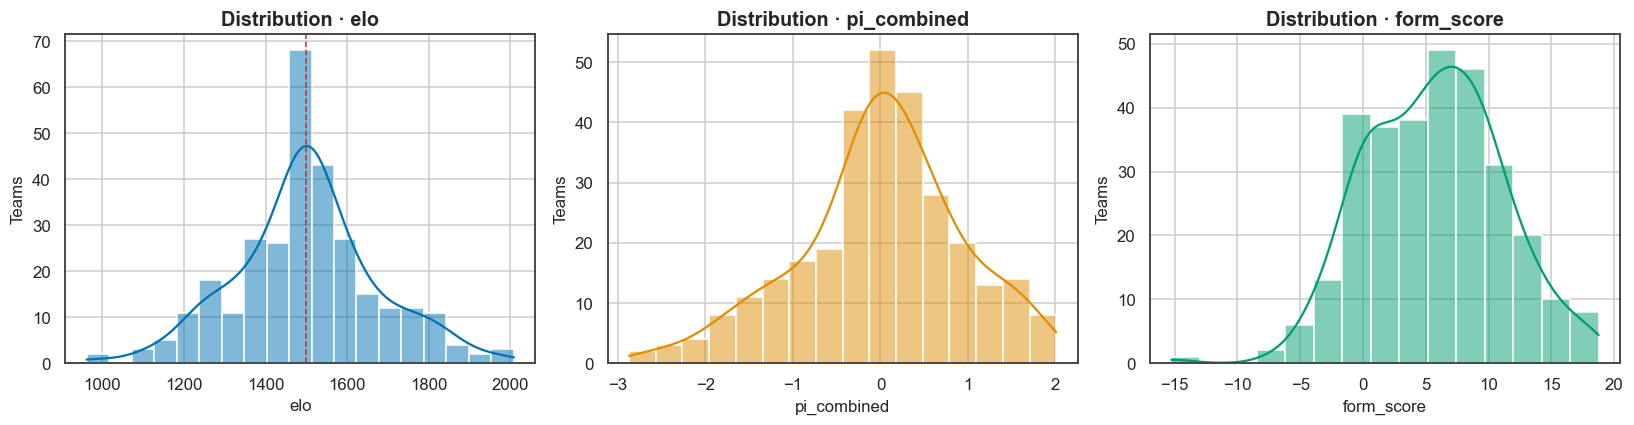

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["elo", "pi_combined", "form_score"], nbs.PALETTE):
    sns.histplot(composite[col], kde=True, ax=ax, color=color)
    ax.set(title=f"Distribution · {col}", xlabel=col, ylabel="Teams")
axes[0].axvline(1500, color="#d62728", ls="--", lw=1)
plt.tight_layout(); plt.show()

## Correlation between rating systems

Strong but not identical — form adds the most independent signal.

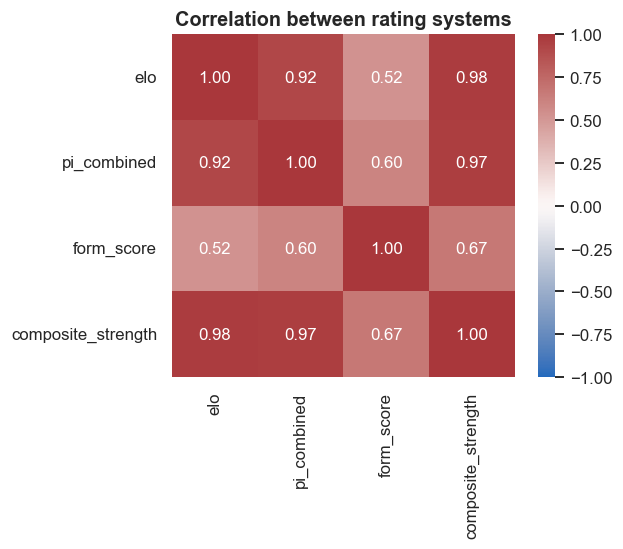

In [3]:
corr = composite[["elo", "pi_combined", "form_score", "composite_strength"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation between rating systems")
plt.tight_layout(); plt.show()

## Talent vs results — squad value vs Elo

The core insight: teams above the diagonal carry more talent than their results imply (under-rated by Elo), and vice-versa.

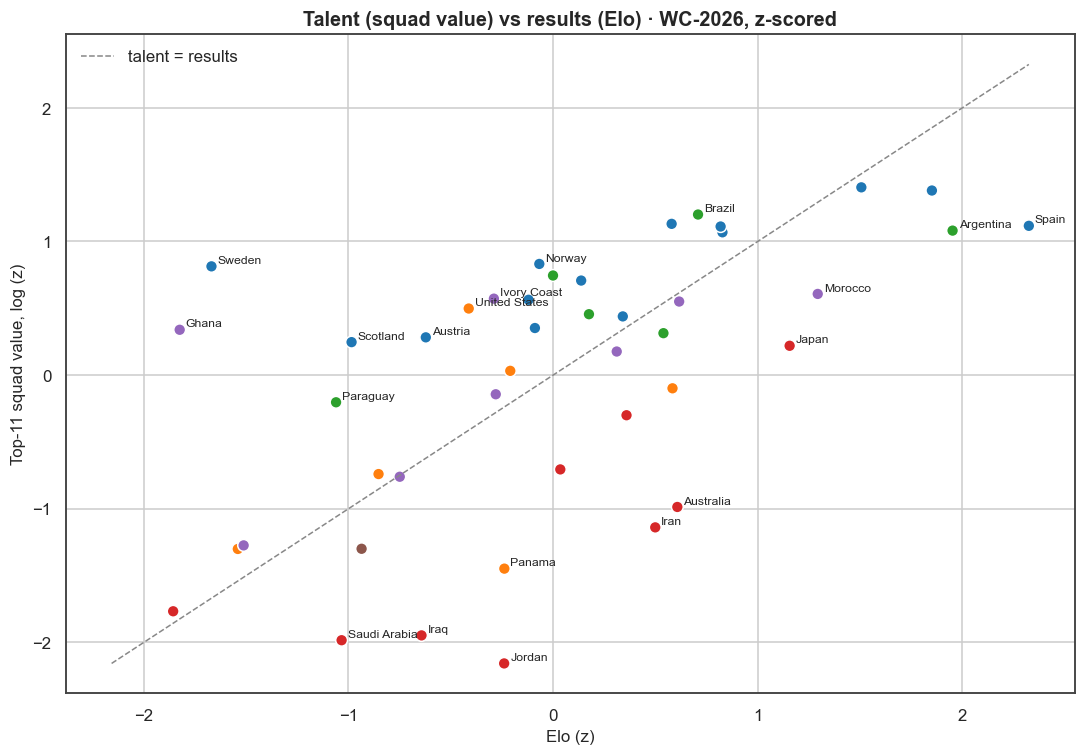

Most UNDER-rated by Elo (talent >> results):
                   elo  top11  residual
team                                   
Sweden         1601.03  472.0      2.48
Ghana          1585.19  243.5      2.16
Scotland       1670.86  214.0      1.23
United States  1729.25  304.0      0.91
Austria        1707.86  225.0      0.90

Most OVER-rated by Elo (results >> talent):
               elo  top11  residual
team                               
Jordan     1746.91   6.60     -1.92
Iran       1822.21  30.30     -1.64
Australia  1833.22  37.70     -1.59
Iraq       1705.72   9.18     -1.30
Panama     1747.01  19.38     -1.21


In [4]:
sv_path = Path("data") / "raw" / "squad_values" / "squad_values.csv"
if not sv_path.exists():
    print("squad_values.csv not found — run scripts/build_squad_values.py to enable this chart.")
else:
    sv = pd.read_csv(sv_path)
    sv26 = sv[sv["as_of_date"] == "2026-06-01"].set_index("team")["squad_value_top11_meur"]
    df = composite.set_index("team")
    df = df.loc[[t for t in wc_teams if t in df.index]].copy()
    df["top11"] = [sv26.get(t, np.nan) for t in df.index]
    df = df.dropna(subset=["top11"])
    df["elo_z"] = (df["elo"] - df["elo"].mean()) / df["elo"].std()
    df["val_z"] = (np.log1p(df["top11"]) - np.log1p(df["top11"]).mean()) / np.log1p(df["top11"]).std()
    df["residual"] = df["val_z"] - df["elo_z"]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(df["elo_z"], df["val_z"], c=[nbs.confederation_color(t) for t in df.index],
               s=60, edgecolor="white")
    lims = [min(df["elo_z"].min(), df["val_z"].min()), max(df["elo_z"].max(), df["val_z"].max())]
    ax.plot(lims, lims, color="#888", ls="--", lw=1, label="talent = results")
    for t, r in df.iterrows():
        if abs(r["residual"]) > 0.8 or t in ("Brazil", "Morocco"):
            ax.annotate(t, (r["elo_z"], r["val_z"]), fontsize=8, xytext=(4, 2),
                        textcoords="offset points")
    ax.set(title="Talent (squad value) vs results (Elo) · WC-2026, z-scored",
           xlabel="Elo (z)", ylabel="Top-11 squad value, log (z)")
    ax.legend(); plt.tight_layout(); plt.show()
    print("Most UNDER-rated by Elo (talent >> results):")
    print(df.sort_values("residual", ascending=False).head(5)[["elo", "top11", "residual"]].round(2).to_string())
    print("\nMost OVER-rated by Elo (results >> talent):")
    print(df.sort_values("residual").head(5)[["elo", "top11", "residual"]].round(2).to_string())

## Strength by confederation

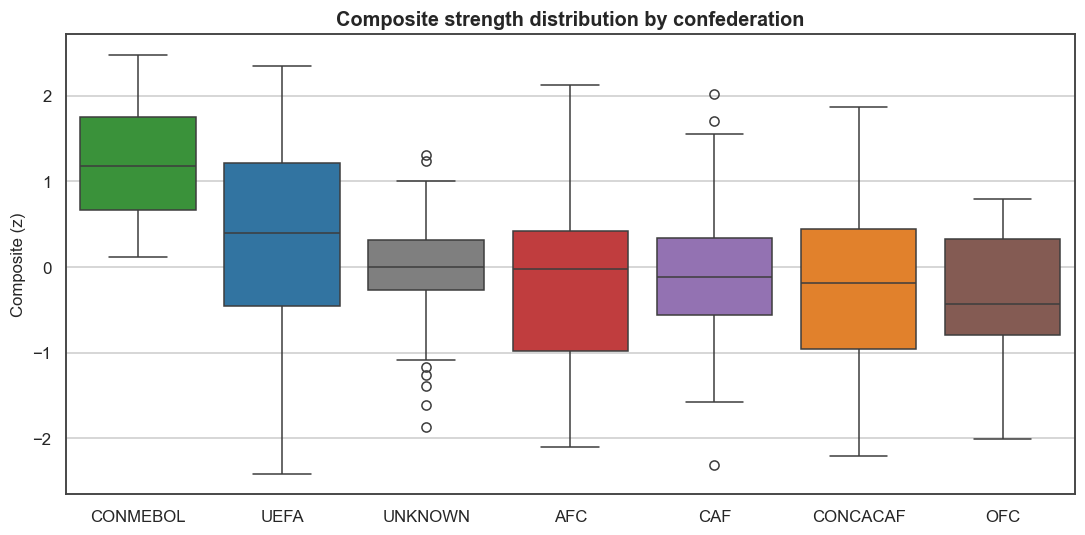

In [5]:
comp = composite.copy()
comp["confederation"] = comp["team"].map(nbs.team_confederation)
order = list(comp.groupby("confederation")["composite_strength"].median().sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=comp, x="confederation", y="composite_strength", order=order,
            hue="confederation", legend=False,
            palette={c: nbs.CONFEDERATION_COLORS.get(c, "#7f7f7f") for c in order}, ax=ax)
ax.set(title="Composite strength distribution by confederation", xlabel="", ylabel="Composite (z)")
plt.tight_layout(); plt.show()

## WC-2026 teams ranked

Coloured by confederation.

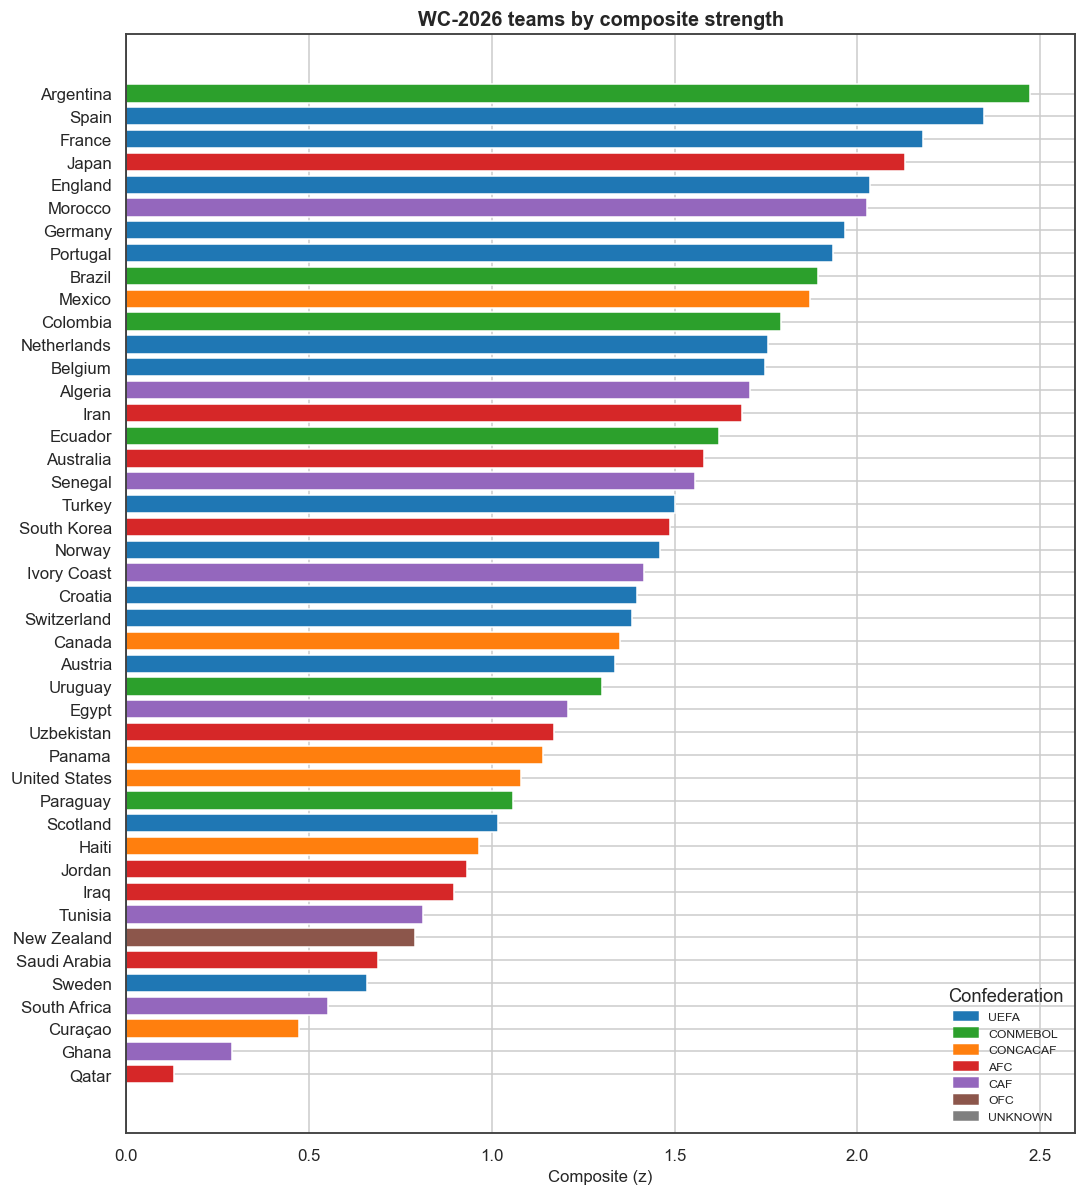

In [6]:
wc_strength = composite[composite["team"].isin(wc_teams)].sort_values("composite_strength")
fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(wc_strength["team"], wc_strength["composite_strength"],
        color=[nbs.confederation_color(t) for t in wc_strength["team"]])
ax.axvline(0, color="black", lw=0.5)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in nbs.CONFEDERATION_COLORS.values()]
ax.legend(handles, list(nbs.CONFEDERATION_COLORS.keys()), title="Confederation", fontsize=8)
ax.set(title="WC-2026 teams by composite strength", xlabel="Composite (z)", ylabel="")
plt.tight_layout(); plt.show()

## Biggest rating disagreements

Where Elo and PI diverge most — the teams whose strength is least certain.

In [7]:
z = composite.copy()
for c in ["elo", "pi_combined"]:
    z[f"{c}_z"] = (z[c] - z[c].mean()) / z[c].std()
z["disagreement"] = (z["elo_z"] - z["pi_combined_z"]).abs()
print("Teams where Elo and PI disagree most (rating uncertainty):")
print(z.sort_values("disagreement", ascending=False).head(10)[
    ["team", "elo", "pi_combined", "disagreement"]].round(3).to_string(index=False))

Teams where Elo and PI disagree most (rating uncertainty):
                    team      elo  pi_combined  disagreement
                  Darfur 1359.339       -2.632         1.994
          American Samoa 1249.476       -2.873         1.618
               Gibraltar 1079.502       -0.875         1.491
              San Marino  961.795       -1.601         1.395
                 Andorra 1123.666       -0.808         1.307
           Liechtenstein  997.298       -1.528         1.268
          Chagos Islands 1386.206       -1.757         1.217
               Lithuania 1232.641       -0.516         0.991
                  France 1960.096        1.575         0.972
Northern Mariana Islands 1353.765       -1.659         0.925


## Key findings

- Elo, PI and form correlate strongly but are not redundant — form carries the most independent signal.
- **Talent vs results:** the scatter exposes the teams whose squad value outstrips their Elo (under-rated) and vice-versa — Brazil and Morocco are the canonical examples that motivated adding squad value.
- UEFA and CONMEBOL dominate the confederation boxplots; long lower tails are the minnows.
- The disagreement table flags teams to predict with caution.